# Notebook 04 — Machine Learning supervisado para estimación de valor de mercado

Este notebook extiende la modelización econométrica desarrollada en los notebooks anteriores mediante modelos supervisados de Machine Learning aplicados al mismo problema analítico: estimar el valor de mercado esperado de futbolistas jóvenes en el mercado europeo.

El objetivo no es sustituir el modelo econométrico, sino evaluar si algoritmos no lineales pueden mejorar la capacidad predictiva out-of-sample manteniendo una interpretación útil para scouting cuantitativo.

La lógica metodológica se mantiene constante respecto al Notebook 03:

- Unidad de análisis: jugador–temporada.
- Target principal: `log_market_value_eur`.
- Validación temporal: train 2019-2020 a 2023-2024 y test 2024-2025.
- Comparación contra el modelo econométrico final.
- Construcción de scores de infravaloración sobre predicciones out-of-sample.

Desde una perspectiva de TFM, este notebook responde a la pregunta:

> ¿Aportan los modelos supervisados de Machine Learning una mejora predictiva significativa respecto al modelo OLS interpretable con efectos fijos?

## 1. Configuración inicial

Se importan las librerías necesarias para manipulación de datos, modelización, evaluación y visualización. Se priorizan modelos de Machine Learning adecuados para datos tabulares y tamaños muestrales moderados.

Modelos incluidos:

- `RandomForestRegressor`: modelo de árboles en ensamblado, robusto ante no linealidades e interacciones.
- `GradientBoostingRegressor`: boosting secuencial, habitualmente competitivo en problemas tabulares.
- `HistGradientBoostingRegressor`: implementación eficiente de gradient boosting incluida en scikit-learn.

No se incluyen redes neuronales porque el tamaño de muestra es limitado y porque la interpretabilidad sigue siendo prioritaria en el proyecto.

In [14]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "player_season_modeling.parquet"

OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Current working dir:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Current working dir: c:\Users\manue\Projects\market-value-football-tfm\notebooks
Project root: c:\Users\manue\Projects\market-value-football-tfm
Dataset path: c:\Users\manue\Projects\market-value-football-tfm\data\processed\player_season_modeling.parquet
Dataset exists: True


## 2. Carga del dataset modelizable

Se utiliza el mismo dataset modelizable que en el modelo econométrico final. Esto garantiza comparabilidad metodológica entre OLS y Machine Learning.

No se reconstruye el pipeline de datos en este notebook: las fases de integración, matching, limpieza y filtrado ya han sido validadas previamente. Aquí se parte del dataset final de modelización para evitar inconsistencias entre notebooks.

In [15]:
df = pd.read_parquet(DATA_PATH)

print("Dataset cargado")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"Players: {df['player_name_fbref'].nunique():,}" if 'player_name_fbref' in df.columns else "player_name_fbref no disponible")
print(f"Seasons: {df['season'].min()} - {df['season'].max()}")

available_cols = sorted(df.columns.tolist())
print("\nPrimeras columnas disponibles:")
print(available_cols[:40])

display(df.head())

Dataset cargado
Rows: 3,297
Columns: 54
Players: 1,847
Seasons: 2019-2020 - 2024-2025

Primeras columnas disponibles:
['age', 'age_diff', 'age_fbref', 'age_tm', 'assists', 'assists_per90', 'club', 'club_score', 'competition_id_tm', 'current_club_id_tm', 'current_club_name_tm', 'date_of_birth', 'delta_log_market_value_1y', 'foot', 'g_a', 'g_a_minus_pk_per90', 'g_a_per90', 'goals', 'goals_minus_pk', 'goals_minus_pk_per90', 'goals_per90', 'height_in_cm', 'league', 'log_market_value_eur', 'market_value_eur', 'market_value_growth_1y', 'market_value_next_eur', 'market_value_prev_eur', 'matches_played', 'matching_confidence', 'matching_method', 'matching_status', 'minutes_played', 'nationality', 'nineties', 'penalties_attempted', 'penalties_scored', 'player_id_tm', 'player_name_fbref', 'player_name_norm']


,player_name_fbref,club,league,season,season_start_year_fbref,position,position_group,age_fbref,matches_played,starts,minutes_played,nineties,goals,assists,g_a,goals_minus_pk,penalties_scored,penalties_attempted,yellow_cards,red_cards,goals_per90,assists_per90,g_a_per90,goals_minus_pk_per90,g_a_minus_pk_per90,player_name_norm,player_id_tm,player_name_tm,season_start_year_tm,valuation_date,market_value_eur,log_market_value_eur,market_value_prev_eur,market_value_next_eur,market_value_growth_1y,delta_log_market_value_1y,age_tm,date_of_birth,nationality,position_tm,sub_position_tm,foot,height_in_cm,current_club_name_tm,current_club_id_tm,competition_id_tm,source,matching_method,matching_confidence,age_diff,club_score,matching_status,season_start_year,age
0,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2022-2023,2022,MF,MID,20.0000,34,29,2651,29.5000,4,2,6,4,0,0,2,0,0.1400,0.0700,0.2000,0.1400,0.2000,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,022.0000",2022-11-11,"1,200,000.0000",13.9978,"800,000.0000","3,000,000.0000",1.5000,0.9163,21.2731,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2731,100.0000,True,2022,21.2731
1,Teden Mengi,Luton Town,Premier League,2023-2024,2023,DF,DEF,21.0000,30,28,2469,27.4000,1,0,1,1,0,0,3,0,0.0400,0.0000,0.0400,0.0400,0.0400,teden mengi,"548,470.0000",Teden Mengi,"2,023.0000",2023-12-19,"7,000,000.0000",15.7614,"2,000,000.0000","12,000,000.0000",0.7143,0.5390,21.6372,2002-04-30 00:00:00,England,Defender,Centre-Back,right,186.0000,Luton Town,"1,031.0000",GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.6372,100.0000,True,2023,21.6372
2,Shurandy Sambo,Sparta Rotterdam,Eredivisie,2022-2023,2022,DF,DEF,20.0000,30,28,2307,25.6000,2,1,3,2,0,0,4,2,0.0800,0.0400,0.1200,0.0800,0.1200,shurandy sambo,"412,937.0000",Shurandy Sambo,"2,022.0000",2022-11-11,"700,000.0000",13.4588,"500,000.0000","3,000,000.0000",3.2857,1.4553,21.2293,2001-08-19 00:00:00,Curacao,Defender,Right-Back,right,174.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2293,100.0000,True,2022,21.2293
3,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2023-2024,2023,MF,MID,21.0000,24,24,2106,23.4000,5,2,7,3,2,2,2,0,0.2100,0.0900,0.3000,0.1300,0.2100,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,023.0000",2023-12-15,"4,500,000.0000",15.3196,"4,500,000.0000","4,500,000.0000",0.0000,0.0000,22.3655,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.3655,100.0000,True,2023,22.3655
4,Jakob Breum,Go Ahead Eagles,Eredivisie,2024-2025,2024,MF,MID,20.0000,26,23,2059,22.9000,10,5,15,10,0,0,4,0,0.4400,0.2200,0.6600,0.4400,0.6600,jakob breum,"657,957.0000",Jakob Breum,"2,024.0000",2024-10-14,"1,500,000.0000",14.2210,"1,000,000.0000","2,300,000.0000",0.5333,0.4274,20.9090,2003-11-17 00:00:00,Denmark,Midfield,Attacking Midfield,right,178.0000,Go Ahead Eagles,"1,435.0000",NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.9090,100.0000,True,2024,20.9090


## 3. Validaciones mínimas de calidad para modelización

Antes de entrenar modelos se comprueba que existen las columnas críticas:

- `log_market_value_eur`: target principal.
- `season_start_year` o `season`: necesarias para split temporal.
- `league`, `position_group`: efectos contextuales y categóricos.
- variables de rendimiento y exposición competitiva.

También se corrige de forma defensiva la variable `season_start_year` si no existe explícitamente.

In [16]:
df = df.copy()

if "season_start_year" not in df.columns:
    if "season" in df.columns:
        df["season_start_year"] = df["season"].astype(str).str[:4].astype(int)
    else:
        raise KeyError("No existe ni season_start_year ni season. No se puede hacer split temporal.")

required_cols = ["log_market_value_eur", "market_value_eur", "season_start_year"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise KeyError(f"Faltan columnas obligatorias: {missing_required}")

print("Validación básica completada")
print(df[["season", "season_start_year", "log_market_value_eur", "market_value_eur"]].head())

Validación básica completada
      season  season_start_year  log_market_value_eur  market_value_eur
0  2022-2023               2022               13.9978    1,200,000.0000
1  2023-2024               2023               15.7614    7,000,000.0000
2  2022-2023               2022               13.4588      700,000.0000
3  2023-2024               2023               15.3196    4,500,000.0000
4  2024-2025               2024               14.2210    1,500,000.0000


## 4. Definición del split temporal

La validación temporal reproduce el uso real del modelo: entrenar con información histórica y evaluar en la temporada futura 2024-2025.

Se evita explícitamente el random split porque mezclar temporadas entre train y test introduciría una evaluación excesivamente optimista y menos realista para un caso de scouting profesional.

In [17]:
TEST_SEASON_YEAR = 2024

train = df[df["season_start_year"] < TEST_SEASON_YEAR].copy()
test = df[df["season_start_year"] == TEST_SEASON_YEAR].copy()

print("Split temporal")
print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print("\nTrain seasons:")
print(train["season"].value_counts().sort_index())
print("\nTest seasons:")
print(test["season"].value_counts().sort_index())

if len(train) == 0 or len(test) == 0:
    raise ValueError("Train o test están vacíos. Revisar season_start_year y TEST_SEASON_YEAR.")

Split temporal
Train rows: 2,745
Test rows: 552

Train seasons:
season
2019-2020    537
2020-2021    536
2021-2022    544
2022-2023    542
2023-2024    586
Name: count, dtype: int64

Test seasons:
season
2024-2025    552
Name: count, dtype: int64


## 5. Selección de variables para Machine Learning

El modelo ML incorpora tres bloques de variables:

1. **Demográficas y exposición competitiva**: edad, minutos y transformaciones de minutos.
2. **Rendimiento deportivo**: goles, asistencias y, si existen, variables de progresión, tiro y defensa.
3. **Contexto competitivo**: liga, temporada, posición y, si está disponible, variables de calidad de matching.

La selección se hace de forma dinámica: el notebook usa las variables avanzadas si existen en el dataset, pero no falla si todavía no están disponibles. Esto permite ejecutar el notebook tanto con el dataset actual como con futuras versiones enriquecidas.

In [18]:
# Variables numéricas candidatas. Se incluyen columnas avanzadas si existen.
numeric_candidates = [
    "age",
    "minutes_played",
    "log_minutes_played",
    "goals_per90",
    "assists_per90",
    "g_a_per90",
    "shots_per90",
    "progressive_passes_per90",
    "progressive_carries_per90",
    "tackles_per90",
    "interceptions_per90",
    "finishing_index",
    "playmaking_index",
    "progression_index",
    "defensive_index",
    "matching_confidence",
    "age_diff",
    "club_score",
]

# Crear log_minutes_played si no existe.
for dataset in [train, test]:
    if "log_minutes_played" not in dataset.columns and "minutes_played" in dataset.columns:
        dataset["log_minutes_played"] = np.log1p(dataset["minutes_played"])

numeric_features = [c for c in numeric_candidates if c in train.columns]

categorical_candidates = [
    "league",
    "position_group",
    "season",
    "matching_method",
]

categorical_features = [c for c in categorical_candidates if c in train.columns]

TARGET = "log_market_value_eur"

print("Numeric features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)
print(f"\nTarget: {TARGET}")

if len(numeric_features) + len(categorical_features) == 0:
    raise ValueError("No hay features disponibles para entrenar modelos.")

Numeric features:
['age', 'minutes_played', 'log_minutes_played', 'goals_per90', 'assists_per90', 'g_a_per90', 'matching_confidence', 'age_diff', 'club_score']

Categorical features:
['league', 'position_group', 'season', 'matching_method']

Target: log_market_value_eur


## 6. Preparación de matrices de modelización

Se separan variables explicativas (`X`) y target (`y`).

El preprocesamiento se encapsula dentro de un `Pipeline` para evitar leakage y garantizar que imputación, escalado y codificación categórica se ajustan únicamente con datos de entrenamiento.

Decisiones:

- Variables numéricas: imputación por mediana y escalado estándar.
- Variables categóricas: imputación por categoría más frecuente y one-hot encoding.

Aunque los modelos de árboles no necesitan escalado, se mantiene una transformación homogénea y controlada dentro del pipeline.

In [19]:
X_train = train[numeric_features + categorical_features].copy()
y_train = train[TARGET].copy()

X_test = test[numeric_features + categorical_features].copy()
y_test = test[TARGET].copy()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (2745, 13)
X_test: (552, 13)
y_train: (2745,)
y_test: (552,)


## 7. Funciones de evaluación

Se utilizan las mismas métricas que en el modelo econométrico:

- MAE logarítmico.
- RMSE logarítmico.
- R² out-of-sample.

Adicionalmente se calcula una traducción aproximada del error logarítmico a factor multiplicativo. Por ejemplo, un RMSE logarítmico de 0.70 implica que el error típico equivale aproximadamente a multiplicar/dividir el valor por `exp(0.70)`.

In [20]:
def regression_metrics(y_true, y_pred, label, split):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan
    return {
        "model": label,
        "split": split,
        "MAE_log": mae,
        "RMSE_log": rmse,
        "R2": r2,
        "RMSE_multiplicative_factor": np.exp(rmse),
    }


def evaluate_model(name, fitted_model):
    pred_train = fitted_model.predict(X_train)
    pred_test = fitted_model.predict(X_test)
    return [
        regression_metrics(y_train, pred_train, name, "train"),
        regression_metrics(y_test, pred_test, name, "test"),
    ], pred_train, pred_test

## 8. Modelo benchmark: media histórica del target

Antes de entrenar modelos complejos, se calcula un baseline nulo que predice siempre la media de entrenamiento. Cualquier modelo útil debe superar claramente este benchmark.

In [21]:
mean_pred_train = np.full(shape=len(y_train), fill_value=y_train.mean())
mean_pred_test = np.full(shape=len(y_test), fill_value=y_train.mean())

results = []
results.append(regression_metrics(y_train, mean_pred_train, "M0_mean_train", "train"))
results.append(regression_metrics(y_test, mean_pred_test, "M0_mean_train", "test"))

pd.DataFrame(results)

,model,split,MAE_log,RMSE_log,R2,RMSE_multiplicative_factor
0,M0_mean_train,train,1.0960,1.3117,0.0000,3.7126
1,M0_mean_train,test,1.0899,1.3212,-0.0059,3.7478


## 9. Definición de modelos supervisados

Se entrenan tres familias de modelos:

1. **Random Forest**: captura no linealidades e interacciones de forma robusta, aunque puede suavizar predicciones extremas.
2. **Gradient Boosting**: modelo secuencial que suele mejorar la precisión en datos tabulares, con mayor riesgo de overfitting si no se regulariza.
3. **HistGradientBoosting**: variante eficiente y regularizada de boosting, útil para comparación.

Los hiperparámetros se mantienen deliberadamente moderados. El objetivo no es maximizar artificialmente el rendimiento, sino construir una comparación sólida y defendible frente al modelo econométrico.

In [22]:
models = {
    "ML1_RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "ML2_GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=10,
        subsample=0.85,
        random_state=RANDOM_STATE,
    ),
    "ML3_HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=31,
        min_samples_leaf=15,
        l2_regularization=0.05,
        random_state=RANDOM_STATE,
    ),
}

pipelines = {
    name: Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    for name, model in models.items()
}

pipelines

{'ML1_RandomForest': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'minutes_played',
                                                    'log_minutes_played',
                                                    'goals_per90',
                                                    'assists_per90', 'g_a_per90',
                                                    'matching_confidence',
                                                    'age_diff', 'club_score']),
                                                  ('cat',
                          

## 10. Entrenamiento y evaluación out-of-sample

Se entrenan los modelos únicamente con el conjunto histórico y se evalúan en la temporada 2024-2025. Esta evaluación representa el criterio principal para comparar modelos, ya que simula el uso real del sistema para detectar oportunidades futuras.

In [23]:
fitted_models = {}
predictions = {
    "M0_mean_train": {
        "train": mean_pred_train,
        "test": mean_pred_test,
    }
}

for name, pipe in pipelines.items():
    print(f"Training {name}...")
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    model_results, pred_train, pred_test = evaluate_model(name, pipe)
    results.extend(model_results)
    predictions[name] = {"train": pred_train, "test": pred_test}

metrics_df = pd.DataFrame(results).sort_values(["split", "RMSE_log"])
metrics_df.to_csv(OUTPUT_DIR / "04_ml_model_metrics.csv", index=False)

display(metrics_df)

Training ML1_RandomForest...
Training ML2_GradientBoosting...
Training ML3_HistGradientBoosting...


,model,split,MAE_log,RMSE_log,R2,RMSE_multiplicative_factor
5,ML2_GradientBoosting,test,0.7613,0.9493,0.4807,2.5838
7,ML3_HistGradientBoosting,test,0.7723,0.9680,0.4600,2.6327
3,ML1_RandomForest,test,0.7704,0.9691,0.4587,2.6356
1,M0_mean_train,test,1.0899,1.3212,-0.0059,3.7478
6,ML3_HistGradientBoosting,train,0.5103,0.6404,0.7616,1.8972
2,ML1_RandomForest,train,0.7043,0.8750,0.5550,2.3988
4,ML2_GradientBoosting,train,0.7135,0.8811,0.5489,2.4134
0,M0_mean_train,train,1.0960,1.3117,0.0000,3.7126


## 11. Comparación contra el modelo econométrico final

Si existe el archivo de métricas del Notebook 03, se incorpora para comparar directamente OLS vs Machine Learning.

Esta comparación es clave para la memoria: el modelo econométrico ofrece interpretabilidad causal/asociativa y explicación económica; los modelos ML pueden aportar mejora predictiva, pero su valor debe justificarse empíricamente.

In [24]:
ols_metrics_path_candidates = [
    OUTPUT_DIR / "03_econometric_model_metrics.csv",
    OUTPUT_DIR / "03_econometric_model_metrics.csv",
    OUTPUT_DIR / "02_baseline_model_metrics.csv",
]

ols_metrics = None
for path in ols_metrics_path_candidates:
    if path.exists():
        ols_metrics = pd.read_csv(path)
        print(f"Métricas econométricas cargadas desde: {path}")
        break

if ols_metrics is not None:
    # Normalizar nombres si hiciera falta.
    common_cols = [c for c in ["model", "split", "MAE_log", "RMSE_log", "R2"] if c in ols_metrics.columns]
    ols_compare = ols_metrics[common_cols].copy()
    ml_compare = metrics_df[["model", "split", "MAE_log", "RMSE_log", "R2"]].copy()
    comparison_df = pd.concat([ols_compare, ml_compare], ignore_index=True)
else:
    print("No se encontró archivo de métricas del Notebook 03. Se muestra solo ML.")
    comparison_df = metrics_df[["model", "split", "MAE_log", "RMSE_log", "R2"]].copy()

comparison_test = comparison_df[comparison_df["split"] == "test"].sort_values("RMSE_log")
comparison_test.to_csv(OUTPUT_DIR / "04_model_comparison_test.csv", index=False)

display(comparison_test)

Métricas econométricas cargadas desde: c:\Users\manue\Projects\market-value-football-tfm\data\outputs\03_econometric_model_metrics.csv


,model,split,MAE_log,RMSE_log,R2
8,ML2_GradientBoosting,test,0.7613,0.9493,0.4807
9,ML3_HistGradientBoosting,test,0.7723,0.9680,0.4600
10,ML1_RandomForest,test,0.7704,0.9691,0.4587
0,M2_base_FE,test,0.7907,0.9823,0.4439
1,M3_final_FE_advanced,test,0.7907,0.9823,0.4439
2,M1_base_no_FE,test,1.0036,1.2165,0.1472
3,M0_mean_train,test,1.0899,1.3212,-0.0059
11,M0_mean_train,test,1.0899,1.3212,-0.0059


## 12. Visualización de rendimiento out-of-sample

Se visualizan las métricas principales en test. La interpretación debe centrarse en la comparación relativa:

- Si ML mejora solo marginalmente a OLS, el modelo econométrico puede seguir siendo la opción principal por interpretabilidad.
- Si ML mejora claramente a OLS, puede usarse como motor predictivo complementario para scoring.

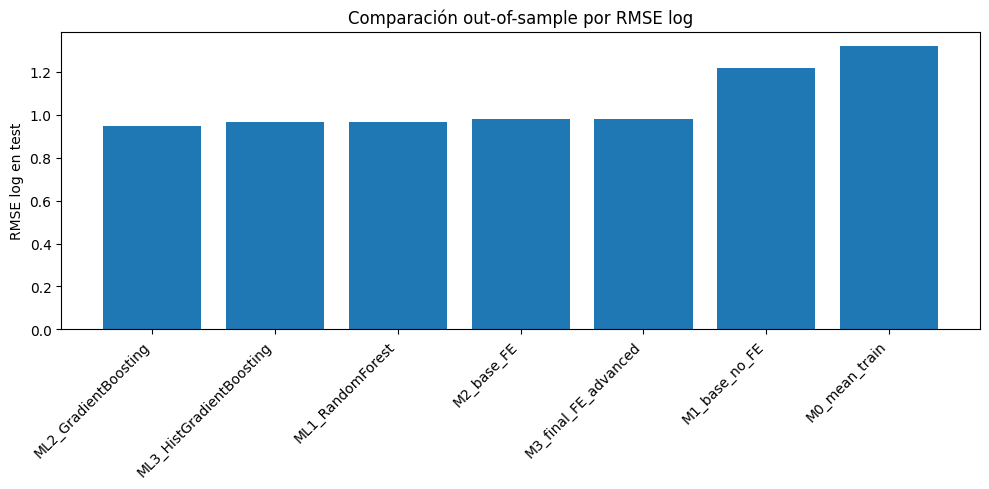

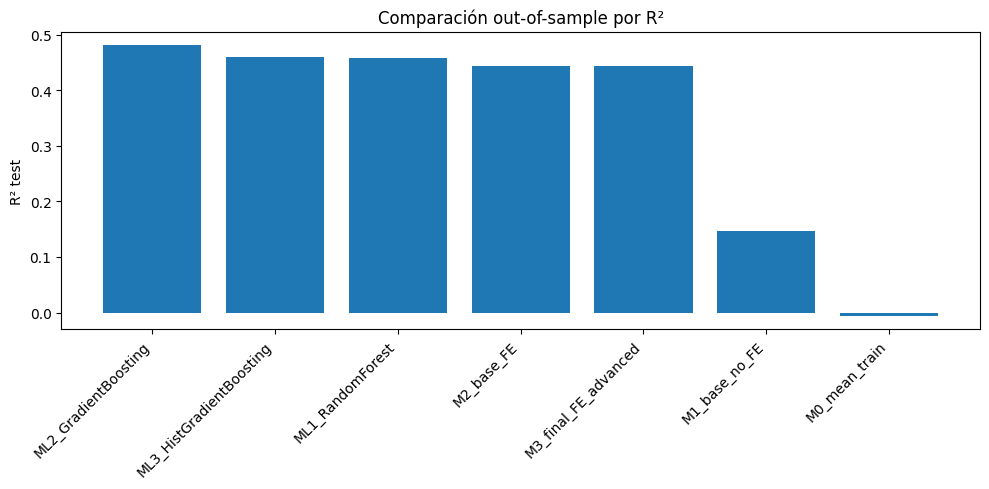

In [25]:
plot_df = comparison_test.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["RMSE_log"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE log en test")
plt.title("Comparación out-of-sample por RMSE log")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R² test")
plt.title("Comparación out-of-sample por R²")
plt.tight_layout()
plt.show()

## 13. Selección del mejor modelo ML

El mejor modelo se selecciona por RMSE logarítmico en test, porque penaliza más los errores grandes y es coherente con el objetivo de estimar valor de mercado.

No obstante, la selección final para negocio no debe depender únicamente del RMSE. También se evaluará la estabilidad del ranking de jugadores infravalorados.

In [26]:
ml_test_metrics = metrics_df[(metrics_df["split"] == "test") & (metrics_df["model"] != "M0_mean_train")].copy()
best_ml_name = ml_test_metrics.sort_values("RMSE_log").iloc[0]["model"]
best_ml_model = fitted_models[best_ml_name]

print(f"Best ML model by test RMSE: {best_ml_name}")
display(ml_test_metrics.sort_values("RMSE_log"))

Best ML model by test RMSE: ML2_GradientBoosting


,model,split,MAE_log,RMSE_log,R2,RMSE_multiplicative_factor
5,ML2_GradientBoosting,test,0.7613,0.9493,0.4807,2.5838
7,ML3_HistGradientBoosting,test,0.7723,0.9680,0.4600,2.6327
3,ML1_RandomForest,test,0.7704,0.9691,0.4587,2.6356


## 14. Predicciones del mejor modelo y transformación a euros

El modelo predice `log_market_value_eur`. Para construir outputs útiles para scouting, se transforma la predicción a euros mediante la exponencial.

Esta transformación permite calcular:

- Valor de mercado esperado.
- Gap absoluto en euros.
- Gap porcentual.
- Inefficiency Score basado en diferencia logarítmica.

In [27]:
test_scored = test.copy()
test_scored["predicted_log_market_value_ml"] = predictions[best_ml_name]["test"]
test_scored["predicted_market_value_ml_eur"] = np.exp(test_scored["predicted_log_market_value_ml"])

test_scored["inefficiency_score_ml"] = (
    test_scored["predicted_log_market_value_ml"] - test_scored["log_market_value_eur"]
)

test_scored["market_value_gap_ml_eur"] = (
    test_scored["predicted_market_value_ml_eur"] - test_scored["market_value_eur"]
)

test_scored["market_value_gap_ml_pct"] = (
    test_scored["predicted_market_value_ml_eur"] / test_scored["market_value_eur"] - 1
)

# Z-score del score dentro del test.
score_std = test_scored["inefficiency_score_ml"].std(ddof=0)
if pd.isna(score_std) or score_std == 0:
    test_scored["inefficiency_score_ml_z"] = 0.0
else:
    test_scored["inefficiency_score_ml_z"] = (
        test_scored["inefficiency_score_ml"] - test_scored["inefficiency_score_ml"].mean()
    ) / score_std

print("Predicciones y scores generados")
display(test_scored[["market_value_eur", "predicted_market_value_ml_eur", "inefficiency_score_ml", "market_value_gap_ml_eur", "market_value_gap_ml_pct"]].head())

Predicciones y scores generados


,market_value_eur,predicted_market_value_ml_eur,inefficiency_score_ml,market_value_gap_ml_eur,market_value_gap_ml_pct
4,"1,500,000.0000","3,215,975.0699",0.7627,"1,715,975.0699",1.1440
5,"1,300,000.0000","850,106.7660",-0.4248,"-449,893.2340",-0.3461
9,"500,000.0000","6,130,168.5575",2.5064,"5,630,168.5575",11.2603
10,"650,000.0000","699,868.9208",0.0739,"49,868.9208",0.0767
15,"1,000,000.0000","785,206.1473",-0.2418,"-214,793.8527",-0.2148


## 15. Construcción del Opportunity Score ML

El `Inefficiency Score` mide la diferencia entre valor estimado y valor observado. Sin embargo, para scouting conviene ajustar el ranking por fiabilidad.

Se construye un `confidence_score_ml` basado en información disponible:

- calidad del matching, si existe;
- penalización por baja muestra de minutos;
- penalización por diferencia de edad en matching, si existe.

El `opportunity_score_ml` combina infravaloración estimada y confianza. Este score no reemplaza al análisis deportivo, sino que prioriza candidatos para revisión.

In [28]:
# Confidence score defensivo y trazable.
test_scored["confidence_score_ml"] = 1.0

if "matching_confidence" in test_scored.columns:
    test_scored["confidence_score_ml"] *= test_scored["matching_confidence"].fillna(0.85).clip(0, 1)

if "minutes_played" in test_scored.columns:
    minutes_factor = (test_scored["minutes_played"] / 900).clip(0.5, 1.0)
    test_scored["confidence_score_ml"] *= minutes_factor

if "age_diff" in test_scored.columns:
    age_penalty = (1 - (test_scored["age_diff"].fillna(0) / 1.5) * 0.15).clip(0.75, 1.0)
    test_scored["confidence_score_ml"] *= age_penalty

# Opportunity score: solo premia infravaloración positiva.
test_scored["opportunity_score_ml"] = (
    test_scored["inefficiency_score_ml_z"].clip(lower=0) * test_scored["confidence_score_ml"]
)

display(test_scored[["inefficiency_score_ml", "inefficiency_score_ml_z", "confidence_score_ml", "opportunity_score_ml"]].describe())

,inefficiency_score_ml,inefficiency_score_ml_z,confidence_score_ml,opportunity_score_ml
count,552.0000,552.0000,552.0000,552.0000
mean,-0.1404,0.0000,0.7168,0.2790
std,0.9397,1.0009,0.1534,0.4240
min,-2.7605,-2.7908,0.3666,0.0000
25%,-0.8182,-0.7219,0.6900,0.0000
50%,-0.1311,0.0100,0.7734,0.0071
75%,0.4702,0.6505,0.8026,0.4605
max,2.7679,3.0978,0.9982,2.5603


## 16. Ranking ML de jugadores potencialmente infravalorados

Se genera un ranking con los jugadores cuyo valor estimado por el modelo ML supera su valor observado de mercado.

Interpretación:

- `inefficiency_score_ml > 0`: posible infravaloración.
- `market_value_gap_ml_eur > 0`: gap absoluto positivo en euros.
- `opportunity_score_ml`: priorización ajustada por confianza.

Este ranking debe considerarse una shortlist cuantitativa para scouting, no una recomendación automática de fichaje.

In [29]:
name_candidates = ["player_name_fbref", "player_name", "player_name_tm"]
name_col = next((c for c in name_candidates if c in test_scored.columns), None)

ranking_cols = [c for c in [
    name_col,
    "player_id_tm",
    "club",
    "current_club_name_tm",
    "league",
    "season",
    "position_group",
    "age",
    "minutes_played",
    "market_value_eur",
    "predicted_market_value_ml_eur",
    "market_value_gap_ml_eur",
    "market_value_gap_ml_pct",
    "log_market_value_eur",
    "predicted_log_market_value_ml",
    "inefficiency_score_ml",
    "inefficiency_score_ml_z",
    "confidence_score_ml",
    "opportunity_score_ml",
    "matching_method",
    "matching_confidence",
    "age_diff",
    "club_score",
] if c is not None and c in test_scored.columns]

undervalued_ml_ranking = (
    test_scored
    .query("inefficiency_score_ml > 0")
    .sort_values(["opportunity_score_ml", "market_value_gap_ml_eur"], ascending=False)
    [ranking_cols]
    .head(50)
    .copy()
)

overvalued_ml_ranking = (
    test_scored
    .query("inefficiency_score_ml < 0")
    .sort_values(["inefficiency_score_ml", "market_value_gap_ml_eur"], ascending=True)
    [ranking_cols]
    .head(50)
    .copy()
)

undervalued_ml_ranking.to_csv(OUTPUT_DIR / "04_ml_undervalued_ranking.csv", index=False)
overvalued_ml_ranking.to_csv(OUTPUT_DIR / "04_ml_overvalued_ranking.csv", index=False)

display(undervalued_ml_ranking.head(20))

,player_name_fbref,player_id_tm,club,current_club_name_tm,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_ml_eur,market_value_gap_ml_eur,market_value_gap_ml_pct,log_market_value_eur,predicted_log_market_value_ml,inefficiency_score_ml,inefficiency_score_ml_z,confidence_score_ml,opportunity_score_ml,matching_method,matching_confidence,age_diff,club_score
9,Lasse Rosenboom,"512,352.0000",Holstein Kiel,Holstein Kiel,Bundesliga,2024-2025,MID,22.9185,1734,"500,000.0000","6,130,168.5575","5,630,168.5575",11.2603,13.1224,15.6287,2.5064,2.8193,0.9081,2.5603,exact_age_club_validated,1.0000,0.9185,100.0000
2226,Mario Martín,"948,273.0000",Valladolid,Getafe Club de Fútbol S. A. D. Team Dubai,LaLiga,2024-2025,MID,20.6023,1748,"500,000.0000","7,962,624.3617","7,462,624.3617",14.9252,13.1224,15.8903,2.7679,3.0978,0.7988,2.4746,exact_age_validated,0.8500,0.6023,20.8333
1093,Yassin Belkhdim,"807,688.0000",Angers,Angers Sporting Club de l'Ouest,Ligue 1,2024-2025,MID,22.6448,1523,"500,000.0000","5,463,702.1404","4,963,702.1404",9.9274,13.1224,15.5136,2.3913,2.6967,0.7952,2.1444,exact_age_validated,0.8500,0.6448,32.4324
2442,Jesus Rodríguez,"1,190,411.0000",Real Betis,Calcio Como,LaLiga,2024-2025,MID,18.8966,1111,"700,000.0000","6,148,496.5885","5,448,496.5885",7.7836,13.4588,15.6317,2.1729,2.4641,0.7738,1.9066,exact_age_validated,0.8500,0.8966,19.0476
447,Antoine Hainaut,"917,375.0000",Parma,Parma Calcio 1913,Serie A,2024-2025,DEF,22.6639,1206,"750,000.0000","6,033,286.5826","5,283,286.5826",7.0444,13.5278,15.6128,2.0850,2.3704,0.7936,1.8811,exact_age_validated,0.8500,0.6639,58.8235
678,Pau Navarro,"1,061,336.0000",Villarreal,Villarreal Club de Fútbol S.A.D.,LaLiga,2024-2025,DEF,19.6496,916,"500,000.0000","3,581,376.8974","3,081,376.8974",6.1628,13.1224,15.0913,1.9689,2.2468,0.7948,1.7857,exact_age_validated,0.8500,0.6496,48.7805
1140,Kévin Danois,"743,496.0000",Auxerre,Association de la Jeunesse auxerroise,Ligue 1,2024-2025,MID,20.2765,1460,"500,000.0000","3,156,734.6229","2,656,734.6229",5.3135,13.1224,14.9650,1.8427,2.1123,0.8265,1.7458,exact_age_validated,0.8500,0.2765,31.8182
392,Gerard Martín,"705,395.0000",Barcelona,Futbol Club Barcelona,LaLiga,2024-2025,DEF,22.6229,1038,"3,000,000.0000","19,445,716.7133","16,445,716.7133",5.4819,14.9141,16.7831,1.8690,2.1404,0.7971,1.7060,exact_age_validated,0.8500,0.6229,60.0000
1133,Clément Akpa,"806,793.0000",Auxerre,Association de la Jeunesse auxerroise,Ligue 1,2024-2025,DEF,22.8693,2486,"1,000,000.0000","6,645,336.9405","5,645,336.9405",5.6453,13.8155,15.7094,1.8939,2.1669,0.7761,1.6818,exact_age_validated,0.8500,0.8693,31.8182
1246,Jérémy Jacquet,"1,004,301.0000",Rennes,Stade Rennais Football Club,Ligue 1,2024-2025,DEF,19.2252,927,"600,000.0000","3,451,567.0699","2,851,567.0699",4.7526,13.3047,15.0543,1.7497,2.0132,0.8309,1.6727,exact_age_validated,0.8500,0.2252,30.3030


## 17. Análisis agregado del Inefficiency Score ML por liga

Este análisis permite identificar si el modelo ML concentra oportunidades en determinadas ligas. Es especialmente relevante para el proyecto porque Eredivisie y Liga Portugal son mercados estratégicos para detectar talento joven potencialmente infravalorado.

Debe interpretarse con cautela: un score medio elevado por liga puede reflejar oportunidades reales, pero también sesgos del modelo o diferencias estructurales no capturadas.

In [30]:
league_score_ml = (
    test_scored
    .groupby("league", dropna=False)
    .agg(
        n=("inefficiency_score_ml", "size"),
        mean_inefficiency_ml=("inefficiency_score_ml", "mean"),
        median_inefficiency_ml=("inefficiency_score_ml", "median"),
        mean_gap_ml_eur=("market_value_gap_ml_eur", "mean"),
        median_gap_ml_eur=("market_value_gap_ml_eur", "median"),
        mean_gap_ml_pct=("market_value_gap_ml_pct", "mean"),
        mean_confidence_ml=("confidence_score_ml", "mean"),
        mean_opportunity_ml=("opportunity_score_ml", "mean"),
    )
    .reset_index()
    .sort_values("mean_inefficiency_ml", ascending=False)
)

league_score_ml.to_csv(OUTPUT_DIR / "04_ml_inefficiency_by_league.csv", index=False)
display(league_score_ml)

,league,n,mean_inefficiency_ml,median_inefficiency_ml,mean_gap_ml_eur,median_gap_ml_eur,mean_gap_ml_pct,mean_confidence_ml,mean_opportunity_ml
2,LaLiga,72,0.1241,0.1703,"-6,180,232.7533","769,600.3155",0.9456,0.7361,0.4519
3,Liga Portugal,60,-0.0293,0.1470,"-2,484,951.3360","231,527.3354",0.4088,0.6753,0.3315
6,Serie A,77,-0.0608,-0.0962,"-2,359,687.2618","-458,460.2779",0.3877,0.6842,0.2580
4,Ligue 1,99,-0.1187,-0.1074,"-4,162,402.9010","-584,879.8589",0.4593,0.7174,0.3009
1,Eredivisie,93,-0.2209,-0.1446,"-2,290,002.4714","-165,843.4687",0.1576,0.7464,0.2621
0,Bundesliga,77,-0.2228,-0.3268,"-7,547,107.2358","-1,787,682.4070",0.3599,0.7204,0.2373
5,Premier League,74,-0.4130,-0.5207,"-10,203,313.3407","-10,323,799.0791",-0.0701,0.7240,0.1253


## 18. Análisis agregado del Inefficiency Score ML por posición

El mercado no valora igual las posiciones. Los atacantes suelen tener primas de mercado superiores por goles y visibilidad, mientras que defensas, centrocampistas y porteros pueden presentar patrones distintos.

Este análisis ayuda a evaluar si el modelo está sesgado hacia determinados perfiles o si identifica oportunidades en posiciones menos visibles.

In [31]:
position_score_ml = (
    test_scored
    .groupby("position_group", dropna=False)
    .agg(
        n=("inefficiency_score_ml", "size"),
        mean_inefficiency_ml=("inefficiency_score_ml", "mean"),
        median_inefficiency_ml=("inefficiency_score_ml", "median"),
        mean_gap_ml_eur=("market_value_gap_ml_eur", "mean"),
        median_gap_ml_eur=("market_value_gap_ml_eur", "median"),
        mean_gap_ml_pct=("market_value_gap_ml_pct", "mean"),
        mean_confidence_ml=("confidence_score_ml", "mean"),
        mean_opportunity_ml=("opportunity_score_ml", "mean"),
    )
    .reset_index()
    .sort_values("mean_inefficiency_ml", ascending=False)
)

position_score_ml.to_csv(OUTPUT_DIR / "04_ml_inefficiency_by_position.csv", index=False)
display(position_score_ml)

,position_group,n,mean_inefficiency_ml,median_inefficiency_ml,mean_gap_ml_eur,median_gap_ml_eur,mean_gap_ml_pct,mean_confidence_ml,mean_opportunity_ml
3,MID,285,-0.1131,-0.1487,"-5,425,953.7300","-747,368.2129",0.4009,0.7233,0.2781
0,ATT,50,-0.1137,0.1424,"-3,229,670.6942","528,925.5440",0.2810,0.6707,0.2829
1,DEF,201,-0.1794,-0.1629,"-4,976,192.7349","-450,996.6857",0.3860,0.7195,0.2883
2,GK,16,-0.2212,-0.2278,"-1,805,951.9675","-576,819.4384",-0.0485,0.7126,0.1645


## 19. Observado vs predicho

El gráfico observado vs predicho permite evaluar visualmente la calibración del modelo. Un modelo perfectamente calibrado situaría los puntos sobre la diagonal.

En modelos de valor de mercado suele observarse mayor error en jugadores de valor extremo, ya que el mercado incorpora factores no observados como duración contractual, reputación, internacionalidad, agencia, lesiones o presión mediática.

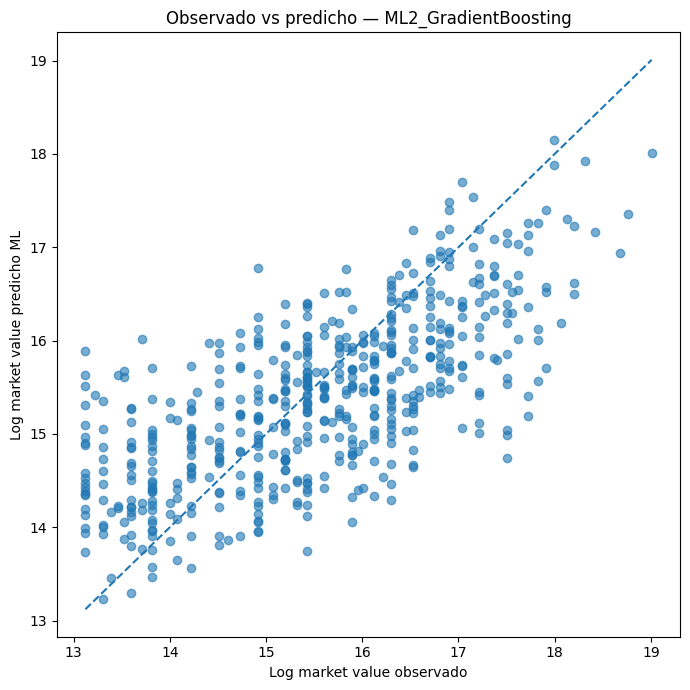

In [32]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_scored["predicted_log_market_value_ml"], alpha=0.6)
min_val = min(y_test.min(), test_scored["predicted_log_market_value_ml"].min())
max_val = max(y_test.max(), test_scored["predicted_log_market_value_ml"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Log market value observado")
plt.ylabel("Log market value predicho ML")
plt.title(f"Observado vs predicho — {best_ml_name}")
plt.tight_layout()
plt.show()

## 20. Distribución de residuos ML

Los residuos permiten analizar sesgos del modelo:

- Residuo positivo: el modelo estima más valor que el mercado observado; posible infravaloración.
- Residuo negativo: el mercado observado supera la estimación; posible sobrevaloración.

La forma de la distribución ayuda a detectar asimetrías y outliers.

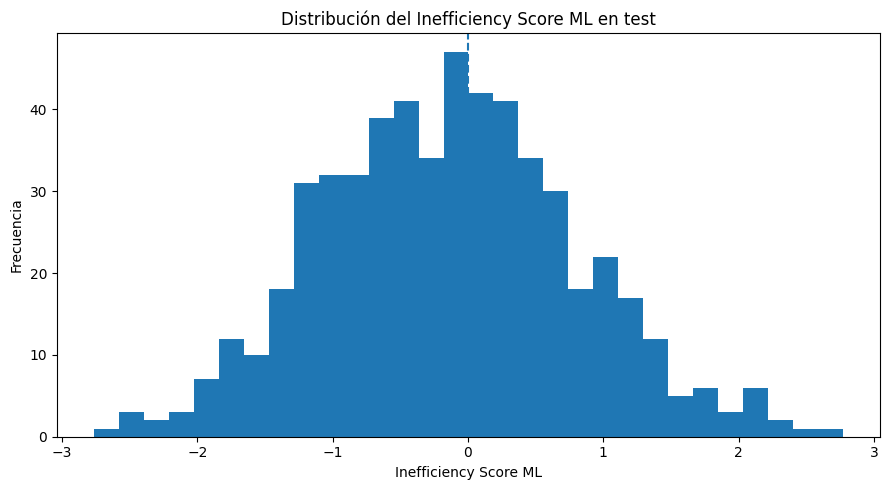

count   552.0000
mean     -0.1404
std       0.9397
min      -2.7605
25%      -0.8182
50%      -0.1311
75%       0.4702
max       2.7679
Name: inefficiency_score_ml, dtype: float64

In [33]:
plt.figure(figsize=(9, 5))
plt.hist(test_scored["inefficiency_score_ml"], bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("Inefficiency Score ML")
plt.ylabel("Frecuencia")
plt.title("Distribución del Inefficiency Score ML en test")
plt.tight_layout()
plt.show()

display(test_scored["inefficiency_score_ml"].describe())

## 21. Importancia de variables por permutation importance

Para mantener interpretabilidad, se calcula `permutation importance` sobre el conjunto de test.

Esta técnica mide cuánto empeora el rendimiento del modelo al permutar aleatoriamente cada variable. Si permutar una variable empeora mucho el modelo, esa variable es importante para la predicción.

Limitación: en presencia de variables correlacionadas, la importancia puede repartirse entre ellas.

,feature,importance_mean,importance_std
9,league,0.4232,0.0271
8,club_score,0.0636,0.0082
5,g_a_per90,0.0562,0.0135
2,log_minutes_played,0.0430,0.0051
1,minutes_played,0.0374,0.0054
4,assists_per90,0.0114,0.0055
0,age,0.0071,0.0022
3,goals_per90,0.0003,0.0028
6,matching_confidence,0.0000,0.0000
12,matching_method,0.0000,0.0000


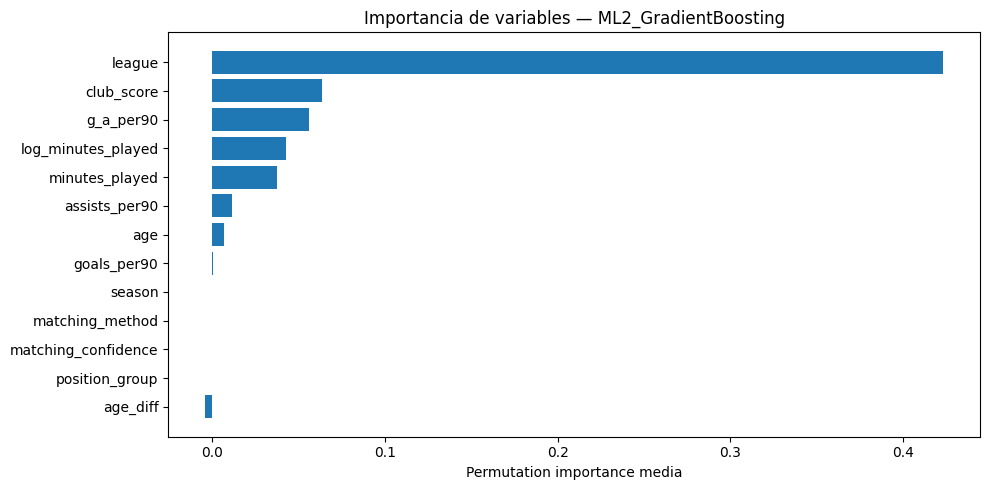

In [34]:
perm = permutation_importance(
    best_ml_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.to_csv(OUTPUT_DIR / "04_ml_permutation_importance.csv", index=False)

display(importance_df)

plt.figure(figsize=(10, 5))
plot_imp = importance_df.head(15).sort_values("importance_mean")
plt.barh(plot_imp["feature"], plot_imp["importance_mean"])
plt.xlabel("Permutation importance media")
plt.title(f"Importancia de variables — {best_ml_name}")
plt.tight_layout()
plt.show()

## 22. Estabilidad del ranking: comparación OLS vs ML

Un buen sistema de scouting no solo debe tener buen RMSE, sino generar rankings razonablemente estables. Si el ranking cambia completamente al cambiar de modelo, la señal de infravaloración es menos fiable.

Si existe el ranking del Notebook 03, se compara el solapamiento entre los principales jugadores infravalorados por OLS y por ML.

In [35]:
ols_ranking_path = OUTPUT_DIR / "03_undervalued_ranking.csv"

if ols_ranking_path.exists():
    ols_rank = pd.read_csv(ols_ranking_path)
    ml_rank = undervalued_ml_ranking.copy()

    # Elegir una clave de comparación robusta.
    possible_keys = ["player_id_tm", "player_name_fbref", "player_name", "player_name_tm"]
    key = next((c for c in possible_keys if c in ols_rank.columns and c in ml_rank.columns), None)

    if key is not None:
        stability_rows = []
        for k in [10, 20, 30, 50]:
            ols_set = set(ols_rank.head(k)[key].dropna().astype(str))
            ml_set = set(ml_rank.head(k)[key].dropna().astype(str))
            overlap = len(ols_set & ml_set)
            stability_rows.append({
                "top_k": k,
                "overlap": overlap,
                "overlap_rate": overlap / k if k else np.nan,
            })
        stability_df = pd.DataFrame(stability_rows)
        stability_df.to_csv(OUTPUT_DIR / "04_ranking_stability_ols_vs_ml.csv", index=False)
        print(f"Clave usada para comparar rankings: {key}")
        display(stability_df)
    else:
        print("No se encontró una clave común fiable para comparar rankings OLS vs ML.")
else:
    print("No existe 03_undervalued_ranking.csv. Se omite comparación OLS vs ML.")

Clave usada para comparar rankings: player_id_tm


,top_k,overlap,overlap_rate
0,10,7,0.7000
1,20,12,0.6000
2,30,18,0.6000
3,50,33,0.6600


## 23. Exportación de predicciones completas

Se exportan las predicciones del mejor modelo ML y los rankings principales para uso posterior en:

- memoria del TFM;
- análisis de scouting;
- dashboard;
- comparación con modelo econométrico;
- construcción del ranking final integrado.

In [36]:
scored_output_cols = [c for c in [
    name_col,
    "player_id_tm",
    "club",
    "current_club_name_tm",
    "league",
    "season",
    "position_group",
    "age",
    "minutes_played",
    "market_value_eur",
    "log_market_value_eur",
    "predicted_log_market_value_ml",
    "predicted_market_value_ml_eur",
    "inefficiency_score_ml",
    "inefficiency_score_ml_z",
    "market_value_gap_ml_eur",
    "market_value_gap_ml_pct",
    "confidence_score_ml",
    "opportunity_score_ml",
    "matching_method",
    "matching_confidence",
    "age_diff",
    "club_score",
] if c is not None and c in test_scored.columns]

test_scored[scored_output_cols].to_parquet(OUTPUT_DIR / "04_ml_test_predictions.parquet", index=False)
test_scored[scored_output_cols].to_csv(OUTPUT_DIR / "04_ml_test_predictions.csv", index=False)

print("Outputs exportados:")
print("- 04_ml_model_metrics.csv")
print("- 04_model_comparison_test.csv")
print("- 04_ml_test_predictions.parquet")
print("- 04_ml_test_predictions.csv")
print("- 04_ml_undervalued_ranking.csv")
print("- 04_ml_overvalued_ranking.csv")
print("- 04_ml_inefficiency_by_league.csv")
print("- 04_ml_inefficiency_by_position.csv")
print("- 04_ml_permutation_importance.csv")

Outputs exportados:
- 04_ml_model_metrics.csv
- 04_model_comparison_test.csv
- 04_ml_test_predictions.parquet
- 04_ml_test_predictions.csv
- 04_ml_undervalued_ranking.csv
- 04_ml_overvalued_ranking.csv
- 04_ml_inefficiency_by_league.csv
- 04_ml_inefficiency_by_position.csv
- 04_ml_permutation_importance.csv


## 24. Conclusiones del Notebook 04

El Notebook 04 introduce modelos supervisados de Machine Learning con el objetivo de evaluar si algoritmos no lineales pueden mejorar la estimación del valor de mercado respecto al modelo econométrico final. Para mantener la comparabilidad metodológica, se utiliza el mismo dataset, el mismo target (`log_market_value_eur`) y la misma partición temporal empleada en el modelo econométrico: entrenamiento con las temporadas 2019-2020 a 2023-2024 y test out-of-sample en 2024-2025.

Los resultados muestran que los modelos de Machine Learning mejoran moderadamente el rendimiento predictivo del modelo OLS con efectos fijos. El mejor modelo es `GradientBoostingRegressor`, que alcanza un MAE logarítmico de 0.7613, un RMSE logarítmico de 0.9493 y un R² out-of-sample de 0.4807. En comparación, el modelo econométrico final alcanzaba un MAE de 0.7907, un RMSE de 0.9823 y un R² de 0.4439. Por tanto, el uso de modelos no lineales aporta una mejora predictiva real, aunque no transformadora.

Desde el punto de vista metodológico, este resultado es coherente con el objetivo del proyecto. El Machine Learning permite capturar relaciones no lineales e interacciones entre variables que el modelo OLS no incorpora de forma explícita. Sin embargo, la mejora limitada sugiere que la capacidad predictiva del sistema no está restringida únicamente por el algoritmo, sino también por el conjunto de variables disponible. En la ejecución actual, las variables deportivas siguen estando concentradas en métricas básicas de output, especialmente goles, asistencias y minutos, por lo que el siguiente salto de calidad dependerá más del enriquecimiento del feature engineering que de aumentar la complejidad algorítmica.

El análisis de importancia de variables confirma una conclusión ya observada en la modelización econométrica: la liga es el principal factor explicativo del valor de mercado. Esto evidencia que el mercado de fichajes incorpora una fuerte prima o descuento estructural según el contexto competitivo en el que juega el futbolista. Junto a la liga, aparecen como relevantes las variables de producción ofensiva y volumen competitivo, especialmente `g_a_per90`, `log_minutes_played` y `minutes_played`.

No obstante, debe señalarse una limitación importante. Algunas variables de calidad del matching, como `club_score`, `matching_confidence`, `age_diff` o `matching_method`, aparecen incluidas en el modelo predictivo. Aunque pueden mejorar el rendimiento estadístico, estas variables no representan características deportivas ni de mercado del jugador, sino indicadores de calidad de integración de datos. Por tanto, su uso debe limitarse preferentemente al cálculo del `Confidence Score`, filtros de robustez y análisis de sensibilidad, evitando que condicionen directamente la estimación del valor esperado.

El ranking de jugadores infravalorados generado por el modelo ML presenta una estabilidad razonable respecto al ranking econométrico. El solapamiento entre ambos modelos alcanza el 70% en el Top 10, el 60% en el Top 20 y el 66% en el Top 50. Este resultado es especialmente relevante desde la perspectiva de negocio, ya que indica que las principales oportunidades detectadas no dependen exclusivamente de una especificación concreta, sino que se mantienen parcialmente estables entre enfoques metodológicos distintos.

En conjunto, el Notebook 04 demuestra que los modelos de Machine Learning aportan valor como extensión predictiva del sistema, pero no sustituyen al modelo econométrico. La recomendación metodológica es mantener el OLS con efectos fijos como modelo principal explicativo e interpretable, y utilizar el Gradient Boosting como modelo complementario para mejorar la precisión, contrastar rankings y reforzar la detección de oportunidades de mercado.